In [1]:
from dataclasses import dataclass
from typing import Optional
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from joblib import Parallel, delayed
from tqdm import tqdm

from spectral_coherence import coherence, lag_window 

import seaborn as sns 
sns.set_style("whitegrid")

# Utils functions
These functions are used to generate the data for the experiments

In [3]:
def generate_ARMA(ar: np.ndarray, ma: np.ndarray, N: int) -> np.ndarray:
    # check that ar and ma are both arrays of the same size
    assert ar.shape[0] == ma.shape[0]
    M = ar.shape[0]

    epsilon = np.random.normal(loc=0, scale=1/np.sqrt(2), size=(N, M)) + 1j * np.random.normal(loc=0, scale=1/np.sqrt(2), size=(N, M))
    y = np.zeros((N, M), dtype='c16')
    y[0, :] = epsilon[0, :]
    for t in range(1, N):
        y[t, :] = ar * y[t-1, :] + epsilon[t, :] + ma * epsilon[t-1, :]
    return y
    
def _ARMA_spectral_density(ar: float, ma: float) -> callable:
    ma_part = lambda nu: 1 + ma**2 + 2*ma*np.cos(2*np.pi*nu)
    ar_part = lambda nu: 1 / (1 + ar**2 - 2*ar*np.cos(2*np.pi*nu))
    return lambda nu: ar_part(nu)*ma_part(nu)

def ARMA_spectral_density(ar: np.ndarray | float, ma: np.ndarray | float) -> callable:
    """ 
    Compute the spectral density of an ARMA(1, 1) process with AR parameter ar and MA parameter ma.
    """
    # check that ar and ma are both arrays or both floats
    assert isinstance(ar, np.ndarray) == isinstance(ma, np.ndarray)

    if isinstance(ar, np.ndarray):
        assert ar.shape == ma.shape
        return lambda nu: np.array([_ARMA_spectral_density(ar[i], ma[i])(nu) for i in range(ar.shape[0])])
    else:
        return _ARMA_spectral_density(ar, ma)

def derivative(f: callable) -> callable:
    """
    Compute the derivative of a function f.
    """
    epsilon = 1e-6
    return lambda x: (f(x+epsilon)-f(x-epsilon))/(2*epsilon)


# Experiment
Below is defined the experiment to run, and the values to return.  

In [38]:
X_MINUS_1_SQUARE = b'\x97\x00|\x00d\x01z\n\x00\x00d\x02z\x08\x00\x00S\x00'

@dataclass(frozen=True)
class Config: 
    N: int # number of samples to generate in the time series
    M: int # dimension of the time series
    B: int # size of the smoothing window for the spectral density estimation
    L: int # number of lags to include in the lag window estimator of the spectral density
    ars: np.ndarray # AR(1) parameters of the time series
    mas: np.ndarray # MA(1) parameters of the time series
    f: callable # function to use in the LSS
    n_max_freqs: Optional[int] = None # number of frequencies to include in the spectral coherence estimator

    def __post_init__(self):
        """ Check that the parameters are valid """
        assert self.ars.shape[0] == self.M
        assert self.mas.shape[0] == self.M

    @property 
    def c_n(self) -> float:
        return self.M / self.B

    @property 
    def f_mp(self) -> callable:
        if config.f.__code__.co_code == X_MINUS_1_SQUARE: 
            f_mp = self.c_n
        else: 
            raise NotImplementedError
        return f_mp 

    @property
    def D_n_term(self) -> float:
        if config.f.__code__.co_code == X_MINUS_1_SQUARE:
            D_n_term = self.c_n
        else:
            raise NotImplementedError
        return D_n_term

        
@dataclass(frozen=True)
class Result: 
    config: Config
    freqs: np.ndarray
    lsss: np.ndarray
    r_n: np.ndarray
    r_n_hat: np.ndarray
    v_n: np.ndarray

    @property 
    def B(self) -> int:
        return self.config.B

    @property 
    def c_n(self) -> float:
        return self.config.c_n

    @property
    def f_mp(self) -> callable:
        return self.config.f_mp

    @property
    def D_n_term(self) -> float:
        return self.config.D_n_term

    @property 
    def correction_term_1(self) -> np.ndarray:
        return self.D_n_term * self.r_n * self.v_n

    @property
    def correction_term_2(self) -> np.ndarray:
        return -self.D_n_term * 1/self.c_n * 1/self.B

    @property 
    def correction_term_1_hat(self) -> np.ndarray:
        return self.D_n_term * self.r_n_hat * self.v_n

    @property
    def theta_n(self) -> np.ndarray:
        return self.lsss - self.f_mp - self.correction_term_1 - self.correction_term_2

    @property
    def theta_n_hat(self) -> np.ndarray:
        return self.lsss - self.f_mp - self.correction_term_1_hat - self.correction_term_2

    @property
    def zeta_1_n(self) -> np.ndarray:
        return np.sum(self.B * self.theta_n) / np.sqrt(len(self.theta_n))

    @property
    def zeta_1_n_hat(self) -> np.ndarray:
        return np.sum(self.B * self.theta_n_hat) / np.sqrt(len(self.theta_n_hat))

    # @property 
    # def sigma_N(self) -> np.ndarray:
    #     return np.sqrt(2 * np.log(self.B))

    @property
    def zeta_2_n(self) -> np.ndarray:
        return np.sum((self.B * self.theta_n)**2) / len(self.theta_n)

    @property
    def zeta_2_n_hat(self) -> np.ndarray:
        std = 1.73**2 # to compute 
        return np.sum((self.B * self.theta_n_hat)**2 - std) / len(self.theta_n_hat)


def run(config: Config) -> Result: 
    """ 
    Run the experiment for a given configuration.
    """
    # generate the ARMA(1, 1) time series
    y = generate_ARMA(config.ars, config.mas, config.N)

    # estimate the spectral coherence from the sample
    C_hats, freqs = coherence(y, config.B, n_max_freqs=config.n_max_freqs)
    n_freqs = len(freqs) # may be less than n_samples if n_max_freqs is not None

    # for each C_hat, compute the Linear Spectral Statistics associated with f 
    eigenvalues = [np.linalg.eigvalsh(C_hat) for C_hat in C_hats]
    lsss = np.array([np.mean(config.f(eigenvalues[n])) for n in range(n_freqs)])

    # compute the corrective terms. first v_n
    b_range = np.arange(-(config.B-1)//2, (config.B-1)//2 + 1)
    v_n = np.mean((b_range/config.N) ** 2)
    
    # then r_n 
    sd = ARMA_spectral_density(config.ars, config.mas)
    sd_prime = derivative(sd)
    values = np.array([sd_prime(freq) / sd(freq) for freq in freqs]) # shape is (n_freq, M)
    r_n = np.mean(values, axis=1)**2

    # finally r_n_hat
    sd_hat = lag_window(y, config.L)
    sd_prime_hat = derivative(sd_hat)
    values = np.array([sd_prime_hat(freq) / sd_hat(freq) for freq in freqs])
    r_n_hat = np.mean(values, axis=1)**2
    
    return Result(config, freqs, lsss, r_n, r_n_hat, v_n)

# Corrective term
In this section we check that the corrective terms computed in the paper are matching with lss - int f d_mp 

/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


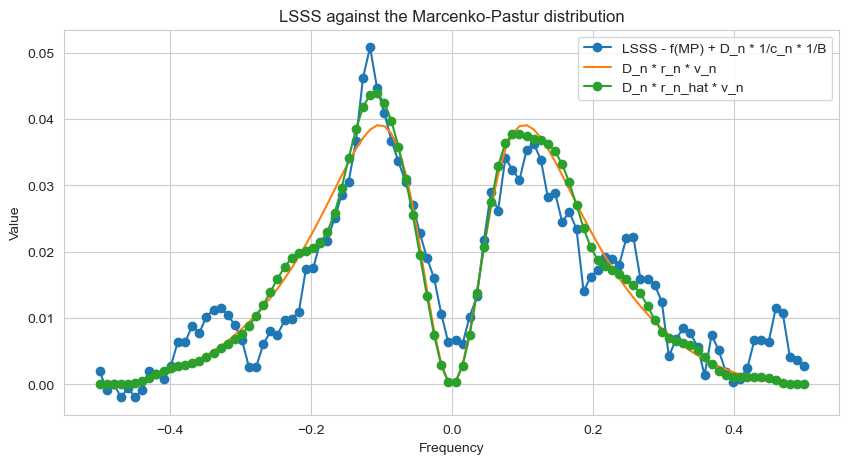

In [63]:
M = 200
config = Config(N=3000, 
                M=M, 
                B=301, 
                L=10, 
                ars=np.random.uniform(low=0.5, high=0.5, size=M),
                mas=-0.5*np.zeros(M), 
                f= lambda x: (x-1)**2,
                n_max_freqs=100)
                
result = run(config)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(result.freqs, result.lsss - result.f_mp - result.correction_term_2, label='LSSS - f(MP) + D_n * 1/c_n * 1/B', marker='o')
ax.plot(result.freqs, result.correction_term_1, label='D_n * r_n * v_n')
ax.plot(result.freqs, result.correction_term_1_hat, label='D_n * r_n_hat * v_n', marker='o')
ax.set_xlabel('Frequency')
ax.set_ylabel('Value')
ax.set_title('LSSS against the Marcenko-Pastur distribution')
ax.legend()
plt.show()

Path('./plots/correction').mkdir(parents=True, exist_ok=True)
fig.savefig('./plots/correction.png', bbox_inches='tight')

/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/p4/9hslrdhx3ys_svm2892373jc0000gn/T/ipykernel_75802/427883979.py:51: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f'./plots/correction/{config.N}.png') for config in configs]


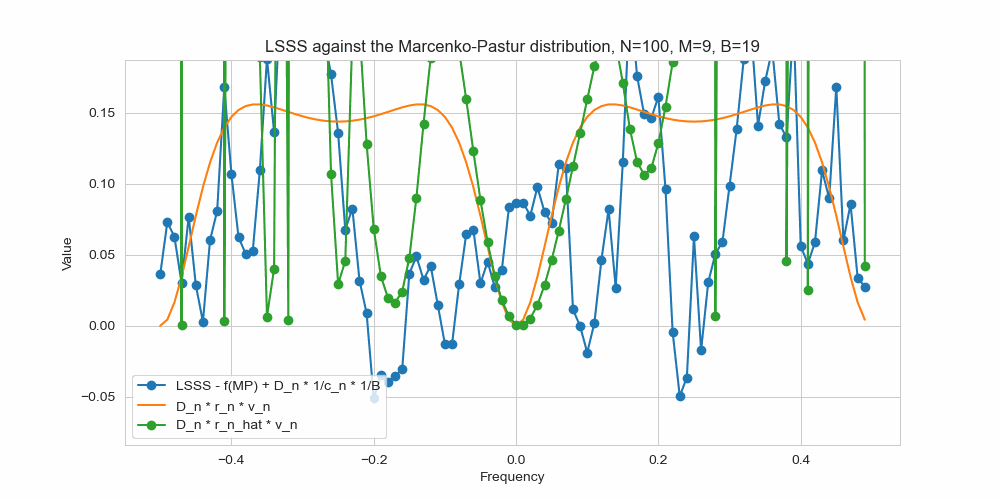

In [64]:
# same figure for a range of increasing N, while M and B scales in the setting defined in the paper 
N_range = np.arange(100, 3100, 300)
alpha, c = 0.8, 0.5

configs = [] 
for N in N_range: 
    M = int(N ** alpha / 4)
    B = int(M / c)
    if B % 2 == 0: # force B to be odd
        B += 1

    ars = np.random.uniform(low=0.5, high=0.5, size=M)
    mas = np.random.uniform(low=0.5, high=0.5, size=M)

    L = round(np.log(N))

    config = Config(N=N, 
                    M=M, 
                    B=B, 
                    L=L, 
                    ars=ars,
                    mas=mas, 
                    f= lambda x: (x-1)**2,
                    n_max_freqs=100)
    configs.append(config)


results = Parallel(n_jobs=-1)(delayed(run)(config) for config in configs)

for config, result in zip(configs, results): 
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(result.freqs, result.lsss - result.f_mp - result.correction_term_2, label='LSSS - f(MP) + D_n * 1/c_n * 1/B', marker='o')
    ax.plot(result.freqs, result.correction_term_1, label='D_n * r_n * v_n')
    ax.plot(result.freqs, result.correction_term_1_hat, label='D_n * r_n_hat * v_n', marker='o')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Value')
    ax.set_title(f'LSSS against the Marcenko-Pastur distribution, N={config.N}, M={config.M}, B={config.B}')

    # force the y axis to be the same, ie min and max of the correction term 1 and 2 with a bit of slack 
    y_min = min(np.min(result.correction_term_1), np.min(result.correction_term_2))
    y_max = max(np.max(result.correction_term_1), np.max(result.correction_term_2))
    slack = 0.15 * (y_max - y_min)
    ax.set_ylim(y_min-slack, y_max+slack)

    ax.legend()
    plt.savefig(f'./plots/correction/{config.N}.png')
    plt.close()

# load all the pictures and create the gif
import imageio
images = [imageio.imread(f'./plots/correction/{config.N}.png') for config in configs]
duration_ms = 1000
imageio.mimsave('./plots/correction/animation.gif', images, duration=duration_ms)

# show the gif in the jupyter cell. restart the gif when it reaches the end
from IPython.display import Image
Image(filename='./plots/correction/animation.gif')

# CLT
In this section we show that the three CLT holds

In [65]:
M = 50
n_max_freqs = 4
# check that n_max_freqs is a perfect square (to make the plots nicer)
assert np.sqrt(n_max_freqs) == int(np.sqrt(n_max_freqs))

config = Config(N=1000,
                M=M,
                B=101,
                L=7,
                ars=0.5*np.ones(M),
                mas=0.5*np.zeros(M),
                f= lambda x: (x-1)**2,
                n_max_freqs=n_max_freqs)
n_repeat = 1000
configs = [config] * n_repeat  
results = Parallel(n_jobs=-1)(delayed(run)(config) for config in tqdm(configs))

100%|██████████| 1000/1000 [01:20<00:00, 12.36it/s]


## CLT for each nu
In this section, we show that the CLT holds for each frequency nu.

/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: us

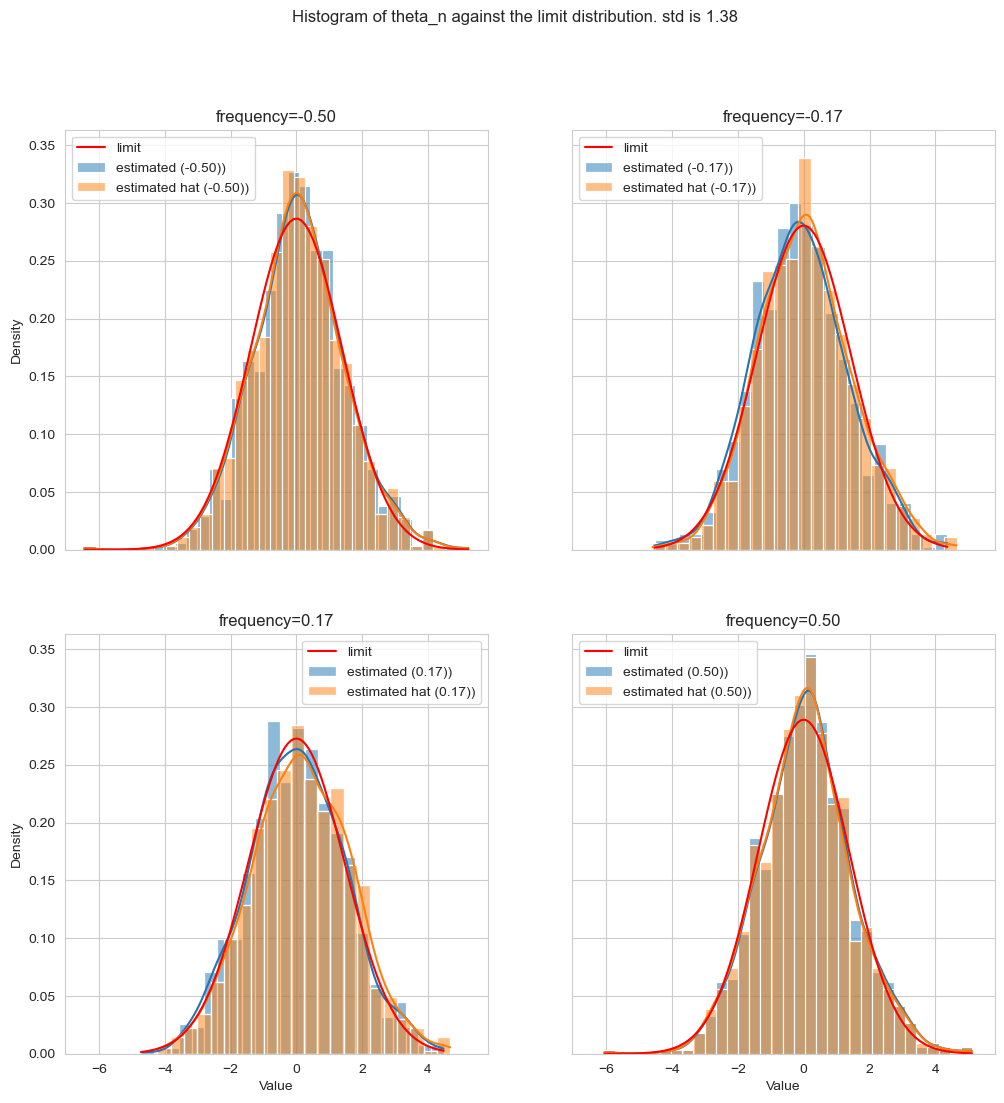

In [66]:
# extract the first theta_n and theta_n_hat
# for each frequency, plot the histogram of the theta_n vs the limit distribution
n_cols, n_rows = int(np.sqrt(n_max_freqs)), int(np.sqrt(n_max_freqs))
size_fig = 6

fig, axs = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(size_fig*n_cols, size_fig*n_rows), sharex=True, sharey=True)
axs = axs.flatten()

freqs = results[0].freqs
for i, freq in enumerate(freqs):
    ax = axs[i]

    # plot the true corrective term
    B_times_theta_ns_freq = np.array([result.B * result.theta_n[i] for result in results])
    sns.histplot(B_times_theta_ns_freq, ax=ax, kde=True, label=f'estimated ({freq:.2f}))', stat='density')

    # plot also the estimated corrective term
    B_times_theta_ns_freq_hat = np.array([result.B * result.theta_n_hat[i] for result in results]).real
    sns.histplot(B_times_theta_ns_freq_hat, ax=ax, kde=True, label=f'estimated hat ({freq:.2f}))', stat='density')

    # add the distribution of the gaussian equivalent 
    # mu, std = stats.norm.fit(config.B * theta_ns_freq)
    mu, std = 0, np.std(B_times_theta_ns_freq)
    x = np.linspace(np.min(B_times_theta_ns_freq), np.max(B_times_theta_ns_freq), num=100)
    ax.plot(x, stats.norm.pdf(x, mu, std), label=f'limit', color='red')

    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.set_title(f'frequency={freq:.2f}')
    ax.legend()

fig.suptitle(f'Histogram of theta_n against the limit distribution. std is {std:.2f}')
plt.show()

# create folder if it does not exist
Path('./plots/clt-single').mkdir(parents=True, exist_ok=True)
fig.savefig('./plots/clt-single/histograms.png')

## CLT for the sum over the frequencies
Here we show that the CLT is valid when summing over frequencies.

/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


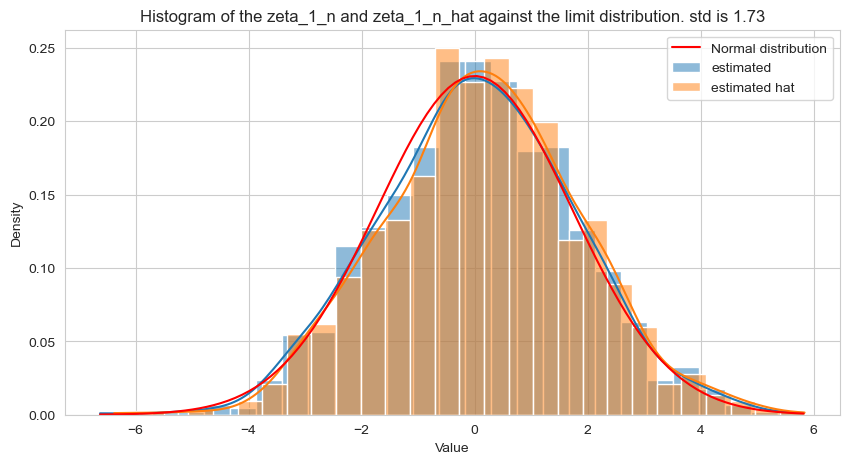

In [67]:
zeta_1_ns = np.array([result.zeta_1_n for result in results])
zeta_1_n_hats = np.array([result.zeta_1_n_hat for result in results])

mu, std = 0, np.std(zeta_1_ns)

# plot histograms of the zeta_1_n and zeta_1_n_hat against the limit distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(zeta_1_ns, ax=ax, kde=True, label=f'estimated', stat='density')
sns.histplot(zeta_1_n_hats.real, ax=ax, kde=True, label=f'estimated hat', stat='density')

# add the distribution of the gaussian equivalent 
x = np.linspace(np.min(zeta_1_ns), np.max(zeta_1_ns), num=100)
ax.plot(x, stats.norm.pdf(x, mu, std), label='Normal distribution', color='red')

ax.legend()
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title(f'Histogram of the zeta_1_n and zeta_1_n_hat against the limit distribution. std is {std:.2f}')
plt.show()

# create folder if it does not exist
Path('./plots/clt-sum').mkdir(parents=True, exist_ok=True)
fig.savefig('./plots/clt-sum/histograms.png')

## CLT for the square

/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alexis/miniconda3/envs/coherence311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


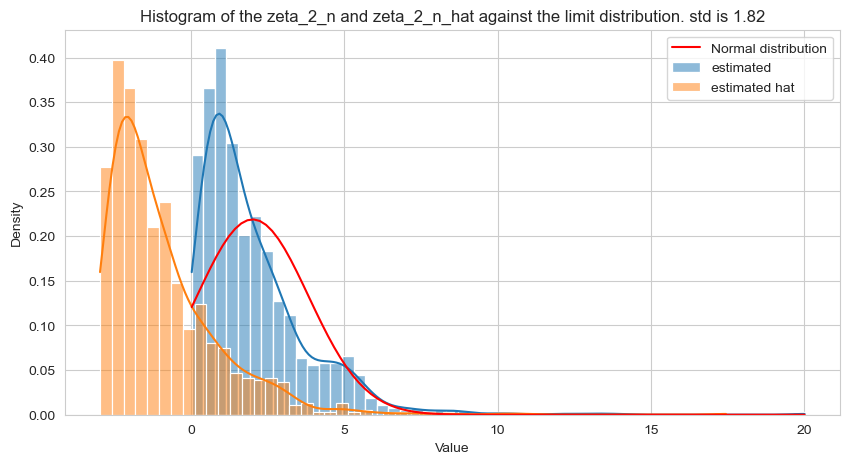

In [69]:
zeta_2_ns = np.array([result.zeta_2_n for result in results])
zeta_2_n_hats = np.array([result.zeta_2_n_hat for result in results])

mu, std = np.mean(zeta_2_ns), np.std(zeta_2_ns)

# plot histograms of the zeta_2_n
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(zeta_2_ns, ax=ax, kde=True, label=f'estimated', stat='density')
sns.histplot(zeta_2_n_hats.real, ax=ax, kde=True, label=f'estimated hat', stat='density')

# add the distribution of the gaussian equivalent 
x = np.linspace(np.min(zeta_2_ns), np.max(zeta_2_ns), num=100)
ax.plot(x, stats.norm.pdf(x, mu, std), label='Normal distribution', color='red')

ax.legend()
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.set_title(f'Histogram of the zeta_2_n and zeta_2_n_hat against the limit distribution. std is {std:.2f}')
plt.show()

# create folder if it does not exist
Path('./plots/clt-sum-2').mkdir(parents=True, exist_ok=True)
fig.savefig('./plots/clt-sum-2/histograms.png')

In [ ]:
np.sqrt(2) * np.std(zeta_1_ns)